# 05 - REPRESENTATIONS TF-IDF ET SIMILARITES

Module 2 : *Apprendre à comparer*. Pour chaque livre, on construit un vecteur TF-IDF, qu'on utilise pour mesurer la similarité entre l'extrait d'un livre inconnu et chaque livre du corpus.

Conformément au sujet, le TF-IDF est implémenté à la main (`pipeline.representations.TfIdfMaison`). On le valide en vérifiant qu'il reproduit exactement `sklearn.TfidfVectorizer` sur un corpus jouet.


## Setup

In [1]:
import sys
from pathlib import Path

# Se déplacer dans le dossier du projet (NE LANCER Q'UNE FOIS)
%cd ../
%ls

/home/gau/projets/nlp/projet_nlp_app
README.md  figures/  notebooks/      pipeline/         scripts/
app/       models/   pg_catalog.csv  requirements.txt


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pipeline.config import BENCH_PARAMS, TFIDF_PARAMS
from pipeline.corpus import charger_corpus, trouver_livre
from pipeline.representations import (
    TfIdfMaison,
    similarites_cosinus,
    similarites_euclidiennes
)

CFG = {
    "figures_dir":         Path("figures"),
    "min_df":              TFIDF_PARAMS["min_df"],
    "max_df_ratio":        TFIDF_PARAMS["max_df_ratio"],
    "n_extraits_par_livre": BENCH_PARAMS["n_extraits_par_livre"],
    "taille_extrait":      BENCH_PARAMS["taille_extrait"],
    "seed":                BENCH_PARAMS["seed"],
}
CFG["figures_dir"].mkdir(exist_ok=True)
rng = np.random.default_rng(CFG["seed"])

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

## Chargement des annotations

In [3]:
corpus = charger_corpus()

Chargement de 26 livres annotes...
  26 livres charges


## Validation contre sklearn

Vérification que `TfIdfMaison` produit exactement la même matrice que `sklearn.TfidfVectorizer` sur un petit corpus jouet. Si l'`assert` passe, on à la garantie que les calculs sur le vrai corpus seront corrects.


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

docs_test = [
    "le chat mange une souris".split(),
    "le chien mange un os".split(),
    "la souris court vite".split(),
]

vec_maison = TfIdfMaison(ngram_max=1, min_df=1, max_df_ratio=1.0)
X_maison = vec_maison.fit_transform(docs_test)

vec_sk = TfidfVectorizer(analyzer=lambda x: x, norm="l2", smooth_idf=True)
X_sk = vec_sk.fit_transform(docs_test).toarray()

vocab_sk = list(vec_sk.get_feature_names_out())
ordre_maison = [vec_maison.index_[t] for t in vocab_sk]
X_maison_aligne = X_maison[:, ordre_maison]

egal = np.allclose(X_maison_aligne, X_sk, atol=1e-10)
diff_max = np.abs(X_maison_aligne - X_sk).max()
print(f"Vocabulaire identique : {sorted(vec_maison.vocabulaire_) == sorted(vocab_sk)}")
print(f"Matrices identiques   : {egal} (diff max = {diff_max:.2e})")
assert egal
print("\nValidation OK : on peut utiliser TfIdfMaison en confiance.")

Vocabulaire identique : True
Matrices identiques   : True (diff max = 0.00e+00)

Validation OK : on peut utiliser TfIdfMaison en confiance.


## Construction des trois matrices TF-IDF du corpus

Trois configurations pour comparer l'effet du choix de tokens et de la taille des n-grammes :

- `lemmes_1g` : lemmes seulement, unigrammes
- `lemmes_12g` : lemmes, uni + bigrammes
- `tokens_12g` : formes flechies, uni + bigrammes


In [5]:
configs = {
    "lemmes_1g":  {"champ": "lemmes", "ngram_max": 1},
    "lemmes_12g": {"champ": "lemmes", "ngram_max": 2},
    "tokens_12g": {"champ": "tokens", "ngram_max": 2},
}

matrices = {}
vectoriseurs = {}

for nom, cfg in configs.items():
    documents = [c[cfg["champ"]] for c in corpus]
    vec = TfIdfMaison(
        ngram_max=cfg["ngram_max"],
        min_df=CFG["min_df"],
        max_df_ratio=CFG["max_df_ratio"],
    )
    X = vec.fit_transform(documents)
    matrices[nom] = X
    vectoriseurs[nom] = vec
    print(f"{nom:12s} : matrice {X.shape}, vocabulaire {len(vec.vocabulaire_):,} termes")


lemmes_1g    : matrice (26, 17992), vocabulaire 17,992 termes
lemmes_12g   : matrice (26, 86985), vocabulaire 86,985 termes
tokens_12g   : matrice (26, 76492), vocabulaire 76,492 termes


## Trois métriques de similarite

- **Cosinus.** Sur des vecteurs L2-normalises, le cosinus se réduit au produit scalaire u . v. Référence en information retrieval.
- **Distance euclidienne.** Sur des vecteurs L2-normalises, d^2 = 2 - 2 cos, donc euclidien et cosinus donnent **le même classement**. On l'inclut quand même, en convertissant en proximité par 1 / (1 + d).
- **Jaccard.** Calcule sur les ensembles de termes (sans fréquences ni IDF) : |A inter B| / |A union B|.


## Démonstration sur un extrait unique

On prend 200 mots aléatoires d'un livre, on calcule les trois similarités, et on regarde le classement.


In [6]:
livre_demo = trouver_livre(corpus, 0)  # premier livre du corpus
print(f"Extrait pris dans : {livre_demo['auteur']} -- {livre_demo['livre']}")

lemmes = livre_demo["lemmes"]
debut = rng.integers(0, len(lemmes) - CFG["taille_extrait"])
extrait_lemmes = lemmes[debut: debut + CFG["taille_extrait"]]
print(f"Position : token {debut} a {debut + CFG['taille_extrait']}")
print(f"Premiers lemmes : {' '.join(extrait_lemmes[:20])}...\n")

vec = vectoriseurs["lemmes_1g"]
X = matrices["lemmes_1g"]
requete = vec.transform([extrait_lemmes])[0]

sims_cos = similarites_cosinus(X, requete)
sims_euc = similarites_euclidiennes(X, requete)
ensembles = [set(c["lemmes"]) for c in corpus]

df_demo = pd.DataFrame({
    "livre":     [c["auteur"] for c in corpus],
    "cosinus":   sims_cos,
    "euclidien": sims_euc
}).sort_values("cosinus", ascending=False).reset_index(drop=True)
df_demo.head(10)

Extrait pris dans : Dumas Alexandre -- Le Comte De Monte Cristo Tome Ii
Position : token 4513 a 4713
Premiers lemmes : oreille parler teresa écoutât timide oeil baissé discours cavalier luigi lire oeil ardent beau jeune homme discours louange sembler terre...



,livre,cosinus,euclidien
0,Sacher Masoch Leopold Ritter Von,0.126438,0.430703
1,Dumas Alexandre,0.084232,0.424928
2,Fusil Louise,0.046744,0.420033
3,Coppee Francois,0.044088,0.419694
4,Weyman Stanley John,0.043396,0.419606
5,Hugo Victor,0.041665,0.419386
6,Zevaco Michel,0.041046,0.419307
7,Morel Emile,0.035973,0.418665
8,France Anatole,0.034750,0.418511
9,Raspe Rudolf Erich,0.032134,0.418182


## Benchmark systématique

Pour chaque livre, on génère `n_extraits_par_livre` extraits aléatoires de `taille_extrait` mots, et pour chaque extrait on calcule les 3 similarités sur les 3 configurations (9 combinaisons par extrait). On enregistre le rang du vrai livre dans chaque classement -- idéal = 1.


In [7]:
extraits = []
for i, c in enumerate(corpus):
    for _ in range(CFG["n_extraits_par_livre"]):
        n_lemmes = len(c["lemmes"])
        n_tokens = len(c["tokens"])
        if min(n_lemmes, n_tokens) <= CFG["taille_extrait"]:
            continue
        debut_l = rng.integers(0, n_lemmes - CFG["taille_extrait"])
        debut_t = rng.integers(0, n_tokens - CFG["taille_extrait"])
        extraits.append({
            "livre_idx": i,
            "source":    c["auteur"],
            "lemmes":    c["lemmes"][debut_l: debut_l + CFG["taille_extrait"]],
            "tokens":    c["tokens"][debut_t: debut_t + CFG["taille_extrait"]],
        })

print(f"{len(extraits)} extraits generes ({CFG['n_extraits_par_livre']} par livre)")

130 extraits generes (5 par livre)


In [8]:
ensembles_lemmes = [set(c["lemmes"]) for c in corpus]
ensembles_tokens = [set(c["tokens"]) for c in corpus]

lignes = []
for ext in extraits:
    cible = ext["livre_idx"]
    for nom_config, cfg in configs.items():
        vec = vectoriseurs[nom_config]
        X = matrices[nom_config]
        champ = cfg["champ"]
        requete_termes = ext[champ]
        requete_vec = vec.transform([requete_termes])[0]

        ensembles = ensembles_lemmes if champ == "lemmes" else ensembles_tokens
        requete_set = set(requete_termes)

        for nom_metrique, sims in [
            ("cosinus",   similarites_cosinus(X, requete_vec)),
            ("euclidien", similarites_euclidiennes(X, requete_vec))
        ]:
            ordre = np.argsort(-sims)
            rang = int(np.where(ordre == cible)[0][0]) + 1
            lignes.append({
                "config":      nom_config,
                "metrique":    nom_metrique,
                "livre_cible": ext["source"],
                "rang":        rang,
                "score_top1":  sims[ordre[0]],
                "score_cible": sims[cible],
            })

resultats = pd.DataFrame(lignes)
print(f"{len(resultats):,} evaluations effectuees")


780 evaluations effectuees


## Récapitulatif des performances

In [9]:
def stats_par_combinaison(df):
    return pd.Series({
        "top_1":       (df["rang"] == 1).mean() * 100,
        "top_3":       (df["rang"] <= 3).mean() * 100,
        "top_5":       (df["rang"] <= 5).mean() * 100,
        "MRR":         (1 / df["rang"]).mean(),
        "rang_median": df["rang"].median(),
    })

tableau = (
    resultats
    .groupby(["config", "metrique"])
    .apply(stats_par_combinaison, include_groups=False)
    .round(2)
    .sort_values("top_1", ascending=False)
)
tableau

top_1  top_3  top_5   MRR  rang_median
config     metrique                                         
lemmes_1g  euclidien  99.23  100.0  100.0  1.00          1.0
           cosinus    99.23  100.0  100.0  1.00          1.0
lemmes_12g euclidien  98.46  100.0  100.0  0.99          1.0
           cosinus    98.46  100.0  100.0  0.99          1.0
tokens_12g cosinus    96.92  100.0  100.0  0.98          1.0
           euclidien  96.92  100.0  100.0  0.98          1.0

## Visualisation des résultats

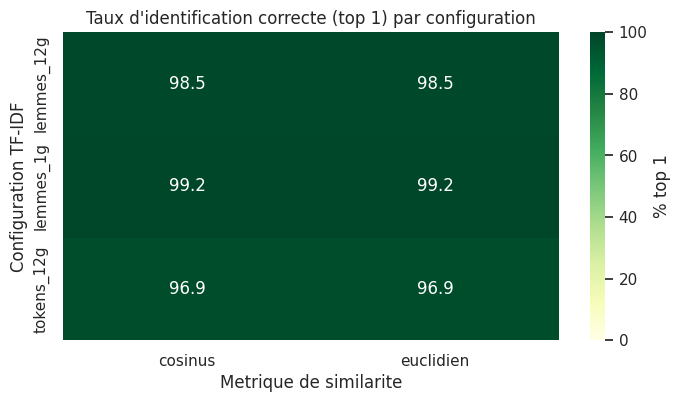

In [10]:
pivot_top1 = (
    resultats
    .assign(top1=resultats["rang"] == 1)
    .groupby(["config", "metrique"])["top1"]
    .mean()
    .mul(100)
    .unstack()
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot_top1, annot=True, fmt=".1f", cmap="YlGn",
            cbar_kws={"label": "% top 1"}, vmin=0, vmax=100, ax=ax)
ax.set_title("Taux d'identification correcte (top 1) par configuration")
ax.set_xlabel("Metrique de similarite")
ax.set_ylabel("Configuration TF-IDF")
plt.savefig(CFG["figures_dir"] / "benchmark_top1.png")
plt.show()

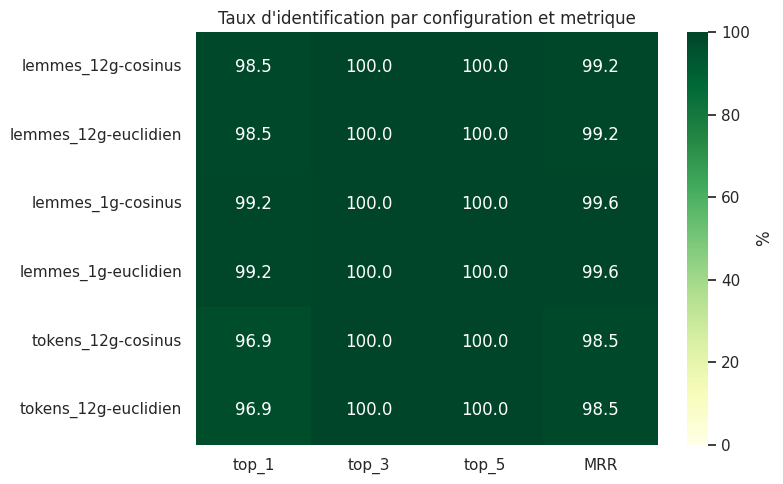

In [11]:
import seaborn as sns

stats = (
    resultats
    .groupby(["config", "metrique"])
    .apply(lambda d: pd.Series({
        "top_1":  (d["rang"] == 1).mean() * 100,
        "top_3":  (d["rang"] <= 3).mean() * 100,
        "top_5":  (d["rang"] <= 5).mean() * 100,
        "MRR":    (1 / d["rang"]).mean() * 100,
    }), include_groups=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(stats, annot=True, fmt=".1f", cmap="YlGn",
            vmin=0, vmax=100, cbar_kws={"label": "%"}, ax=ax)
ax.set_title("Taux d'identification par configuration et metrique")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Analyse des échecs

Quels livres sont les plus difficiles à identifier ? Sur la meilleure configuration, on regarde les extraits ou le rang du vrai livre est > 1.


In [12]:
config_best, metrique_best = tableau.index[0]
meilleure = tableau.iloc[0]
print(f"Meilleure combinaison : {config_best} + {metrique_best} ({meilleure['top_1']:.1f}% top 1)\n")

echecs = resultats[
    (resultats["config"] == config_best)
    & (resultats["metrique"] == metrique_best)
    & (resultats["rang"] > 1)
]
if len(echecs) == 0:
    print("Aucune erreur sur la meilleure configuration.")
else:
    print(f"{len(echecs)} extraits mal classes :")
    print(
        echecs.groupby("livre_cible")
        .agg(n_echecs=("rang", "size"),
             rang_moyen=("rang", "mean"),
             rang_max=("rang", "max"))
        .sort_values("n_echecs", ascending=False)
    )


Meilleure combinaison : lemmes_1g + euclidien (99.2% top 1)

1 extraits mal classes :
                 n_echecs  rang_moyen  rang_max
livre_cible                                    
Dumas Alexandre         1         2.0         2


## Conclusions

Quelques pistes d'analyse pour le rapport :

1. **Cosinus vs euclidien** : sur des vecteurs L2-normalises, les deux donnent le meme classement (||u-v||^2 = 2 - 2 u . v). Verifier dans le tableau que les colonnes cosinus et euclidien ont les memes top 1, top 3, top 5.
2. **Jaccard vs TF-IDF** : Jaccard ignore les frequences et l'IDF. Moins discriminant sur les mots frequents partages.
3. **Bigrammes** : explosion du vocabulaire pour un gain marginal en top 1, mais peut aider sur les expressions distinctives ("docteur Pascal").
